<a href="https://colab.research.google.com/github/shiblidata/dhaka-stock-exchange-market-analysis/blob/main/01_data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dhaka Stock Exchange Market Analysis

## 01 - Data Understanding

### Objective
The purpose of this notebook is to understand the structure, size,
data types, coverage, and basic quality of the Dhaka Stock Exchange
end-of-day financial dataset before performing data cleaning and analysis.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import os

dataset_path = "/content/drive/MyDrive/DSE_Market_Analysis"

os.listdir(dataset_path)

['.DS_Store',
 'metadata',
 'Company Separated UnAdjusted Data',
 'Company Separated Adjusted Data',
 'Full Raw Data']

In [8]:
full_raw_path = dataset_path + "/Full Raw Data"
metadata_path = dataset_path + "/metadata"

print("Full Raw Data:")
print(os.listdir(full_raw_path))

print("\nMetadata:")
print(os.listdir(metadata_path))

Full Raw Data:
['UnAdjusted.csv', 'Adjusted.csv']

Metadata:
['availability_matrix.csv', 'company_metadata.csv', 'date_coverage_summary.csv']


In [9]:
import os

print(os.listdir(metadata_path))

['availability_matrix.csv', 'company_metadata.csv', 'date_coverage_summary.csv']


In [10]:
metadata_file = metadata_path + "/company_metadata.csv"

metadata = pd.read_csv(metadata_file)

metadata.head()

,Ticker,Instrument_Type,First_Date,Last_Date,Calendar_Days,Days_Adjusted,Days_Unadjusted,Days_Both,Coverage_Ratio
0,00DS30,Index,2013-01-04,2026-12-01,5080,3095,3095,3094,0.61
1,00DSES,Index,2014-01-04,2026-12-01,4715,2862,2862,2861,0.61
2,00DSEX,Index,2012-01-10,2026-12-01,5440,3172,3172,3171,0.58
3,00DSMEX,Index,2022-01-09,2026-12-01,1788,804,472,472,0.26
4,1JANATAMF,MutualFund,2012-01-10,2026-12-01,5440,3114,3113,3113,0.57


In [11]:
metadata.shape

(486, 9)

In [12]:
metadata.columns

Index(['Ticker', 'Instrument_Type', 'First_Date', 'Last_Date', 'Calendar_Days',
       'Days_Adjusted', 'Days_Unadjusted', 'Days_Both', 'Coverage_Ratio'],
      dtype='object')

In [13]:
metadata["Instrument_Type"].value_counts()

,count
Instrument_Type,
Equity,395
TreasuryBill,55
MutualFund,24
Bond,7
Index,4
Sukuk,1


In [14]:
metadata.isnull().sum()

,0
Ticker,0
Instrument_Type,0
First_Date,0
Last_Date,0
Calendar_Days,0
Days_Adjusted,0
Days_Unadjusted,0
Days_Both,0
Coverage_Ratio,0


In [15]:
metadata["Ticker"].duplicated().sum()

np.int64(0)

In [16]:
metadata[metadata["Ticker"].duplicated()]

,Ticker,Instrument_Type,First_Date,Last_Date,Calendar_Days,Days_Adjusted,Days_Unadjusted,Days_Both,Coverage_Ratio


In [17]:
metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 486 entries, 0 to 485
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Ticker           486 non-null    object 
 1   Instrument_Type  486 non-null    object 
 2   First_Date       486 non-null    object 
 3   Last_Date        486 non-null    object 
 4   Calendar_Days    486 non-null    int64  
 5   Days_Adjusted    486 non-null    int64  
 6   Days_Unadjusted  486 non-null    int64  
 7   Days_Both        486 non-null    int64  
 8   Coverage_Ratio   486 non-null    float64
dtypes: float64(1), int64(4), object(4)
memory usage: 34.3+ KB


In [18]:
adjusted_file = full_raw_path + "/Adjusted.csv"

adjusted_df = pd.read_csv(adjusted_file)

adjusted_df.head()

,Date,Ticker,Open,High,Low,Close,Volume
0,2012-10-01,00DSEX,"4,418.58","4,500.74","4,367.54","4,462.26",7835350400
1,2012-10-01,1JANATAMF,8.00,8.80,8.00,8.60,1536500
2,2012-10-01,1STPRIMFMF,21.90,23.20,19.50,23.20,1636000
3,2012-10-01,AAMRATECH,42.30,46.13,40.61,44.77,2630100
4,2012-10-01,ABBANK,21.14,22.39,21.02,21.85,1085339


In [19]:
adjusted_df.shape

(1080313, 7)

In [20]:
adjusted_df.columns

Index(['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')

In [21]:
adjusted_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080313 entries, 0 to 1080312
Data columns (total 7 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   Date    1080313 non-null  object 
 1   Ticker  1080313 non-null  object 
 2   Open    1080313 non-null  float64
 3   High    1080313 non-null  float64
 4   Low     1080313 non-null  float64
 5   Close   1080313 non-null  float64
 6   Volume  1080313 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 57.7+ MB


In [22]:
adjusted_df.head(10)

,Date,Ticker,Open,High,Low,Close,Volume
0,2012-10-01,00DSEX,"4,418.58","4,500.74","4,367.54","4,462.26",7835350400
1,2012-10-01,1JANATAMF,8.00,8.80,8.00,8.60,1536500
2,2012-10-01,1STPRIMFMF,21.90,23.20,19.50,23.20,1636000
3,2012-10-01,AAMRATECH,42.30,46.13,40.61,44.77,2630100
4,2012-10-01,ABBANK,21.14,22.39,21.02,21.85,1085339
5,2012-10-01,ACI,67.83,68.26,66.96,67.66,7425
6,2012-10-01,ACIFORMULA,63.05,65.71,61.90,64.38,46800
7,2012-10-01,ACTIVEFINE,25.54,25.78,24.79,25.27,2503313
8,2012-10-01,AFTABAUTO,95.99,97.28,92.45,95.24,1050350
9,2012-10-01,AGNISYSL,27.55,30.70,27.55,30.62,4709320


In [23]:
adjusted_df.tail(10)

,Date,Ticker,Open,High,Low,Close,Volume
1080303,2026-01-22,VFSTDL,12.20,12.50,12.10,12.20,408422
1080304,2026-01-22,WALTONHIL,384.10,386.70,382.20,384.20,23981
1080305,2026-01-22,WATACHEM,138.30,138.70,135.50,136.40,50277
1080306,2026-01-22,WEBCOATS,14.30,14.30,13.20,13.30,92352
1080307,2026-01-22,WMSHIPYARD,8.50,9.10,8.00,8.10,662277
1080308,2026-01-22,WONDERTOYS,24.40,24.40,21.60,22.30,13579
1080309,2026-01-22,YPL,16.10,16.10,15.60,15.70,83934
1080310,2026-01-22,ZAHEENSPIN,3.90,4.00,3.90,3.90,11734
1080311,2026-01-22,ZAHINTEX,6.10,6.10,5.90,5.90,34503
1080312,2026-01-22,ZEALBANGLA,138.90,138.90,130.30,131.10,14953


In [24]:
adjusted_df["Date"] = pd.to_datetime(
    adjusted_df["Date"],
    format="%Y-%m-%d"
)

In [25]:
adjusted_df["Date"].dtype

dtype('<M8[ns]')

In [26]:
print("Start Date:", adjusted_df["Date"].min())
print("End Date:", adjusted_df["Date"].max())

Start Date: 2012-10-01 00:00:00
End Date: 2026-01-22 00:00:00


In [27]:
adjusted_df.isnull().sum().sum()

np.int64(0)

In [28]:
adjusted_df.duplicated().sum()

np.int64(0)

In [29]:
adjusted_df["Ticker"].nunique()

486

In [30]:
price_columns = ["Open", "High", "Low", "Close"]

for col in price_columns:
    count = (adjusted_df[col] <= 0).sum()
    print(f"{col} <= 0 :", count)

Open <= 0 : 27
High <= 0 : 4
Low <= 0 : 29
Close <= 0 : 0


In [31]:
print("Negative Volume:", (adjusted_df["Volume"] < 0).sum())
print("Zero Volume:", (adjusted_df["Volume"] == 0).sum())

Negative Volume: 0
Zero Volume: 447


In [32]:
print(
    "High < Low:",
    (adjusted_df["High"] < adjusted_df["Low"]).sum()
)

print(
    "High < Open:",
    (adjusted_df["High"] < adjusted_df["Open"]).sum()
)

print(
    "High < Close:",
    (adjusted_df["High"] < adjusted_df["Close"]).sum()
)

print(
    "Low > Open:",
    (adjusted_df["Low"] > adjusted_df["Open"]).sum()
)

print(
    "Low > Close:",
    (adjusted_df["Low"] > adjusted_df["Close"]).sum()
)

High < Low: 0
High < Open: 178
High < Close: 4
Low > Open: 1053
Low > Close: 9


In [33]:
invalid_ohlc = adjusted_df[
    (adjusted_df["High"] < adjusted_df["Low"]) |
    (adjusted_df["High"] < adjusted_df["Open"]) |
    (adjusted_df["High"] < adjusted_df["Close"]) |
    (adjusted_df["Low"] > adjusted_df["Open"]) |
    (adjusted_df["Low"] > adjusted_df["Close"])
]

invalid_ohlc.shape

(1233, 7)

In [34]:
invalid_ohlc.head(20)

,Date,Ticker,Open,High,Low,Close,Volume
1676,2012-10-09,MAKSONSPIN,19.59,21.50,20.32,21.50,1770064
12887,2012-12-19,BDLAMPS,98.98,100.58,99.69,99.69,2150
12983,2012-12-19,LINDEBD,540.91,542.57,542.57,542.57,102
12985,2012-12-19,MAKSONSPIN,16.24,16.78,16.33,16.51,241448
16393,2013-01-10,BSCPLC,110.70,112.17,112.17,110.61,230
16566,2013-01-10,SQURPHARMA,70.23,71.31,71.31,70.69,232
20622,2013-02-04,00DSEX,"4,163.83","4,164.62","4,164.62","4,164.62",3552840000
67414,2013-11-07,00DS30,"1,435.15","1,457.63","1,435.16","1,453.33",4738980000
74869,2013-12-17,JMISMDL,165.44,176.47,176.47,166.62,500
110222,2014-06-26,BSC,50.50,52.23,51.83,52.23,100


In [35]:
invalid_prices = adjusted_df[
    (adjusted_df["Open"] <= 0) |
    (adjusted_df["High"] <= 0) |
    (adjusted_df["Low"] <= 0) |
    (adjusted_df["Close"] <= 0)
]

invalid_prices.shape

(48, 7)

In [36]:
equity_tickers = metadata.loc[
    metadata["Instrument_Type"] == "Equity",
    "Ticker"
]

equity_tickers.head()

,Ticker
6,AAMRANET
7,AAMRATECH
9,ABBANK
11,ACFL
12,ACHIASF


In [37]:
equity_tickers.nunique()

395

In [38]:
equity_adjusted = adjusted_df[
    adjusted_df["Ticker"].isin(equity_tickers)
].copy()

In [39]:
print("Equity dataset shape:", equity_adjusted.shape)
print("Unique equity tickers:", equity_adjusted["Ticker"].nunique())

Equity dataset shape: (1002809, 7)
Unique equity tickers: 395


In [40]:
equity_adjusted.head()

,Date,Ticker,Open,High,Low,Close,Volume
3,2012-10-01,AAMRATECH,42.30,46.13,40.61,44.77,2630100
4,2012-10-01,ABBANK,21.14,22.39,21.02,21.85,1085339
5,2012-10-01,ACI,67.83,68.26,66.96,67.66,7425
6,2012-10-01,ACIFORMULA,63.05,65.71,61.90,64.38,46800
7,2012-10-01,ACTIVEFINE,25.54,25.78,24.79,25.27,2503313


In [41]:
print("Start Date:", equity_adjusted["Date"].min())
print("End Date:", equity_adjusted["Date"].max())

print("\nMissing Values:")
print(equity_adjusted.isnull().sum())

print("\nDuplicate Date-Ticker:")
print(
    equity_adjusted.duplicated(
        subset=["Date", "Ticker"]
    ).sum()
)

Start Date: 2012-10-01 00:00:00
End Date: 2026-01-22 00:00:00

Missing Values:
Date      0
Ticker    0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Duplicate Date-Ticker:
0


In [42]:
unadjusted_file = full_raw_path + "/UnAdjusted.csv"

unadjusted_df = pd.read_csv(unadjusted_file)

unadjusted_df.head()

,Date,Ticker,Open,High,Low,Close,Volume
0,2012-10-01,00DSEX,"4,418.58","4,500.74","4,367.54","4,462.26",78353504
1,2012-10-01,1JANATAMF,8.00,8.80,8.00,8.60,1536500
2,2012-10-01,1STPRIMFMF,21.90,23.20,19.50,23.20,1636000
3,2012-10-01,AAMRATECH,65.10,71.00,62.50,68.90,1992500
4,2012-10-01,ABBANK,36.00,38.10,35.80,37.20,712400


In [43]:
unadjusted_df.shape

(1073053, 7)

In [44]:
unadjusted_df["Date"] = pd.to_datetime(
    unadjusted_df["Date"],
    format="%Y-%m-%d"
)

In [45]:
print("Start Date:", unadjusted_df["Date"].min())
print("End Date:", unadjusted_df["Date"].max())

Start Date: 2012-10-01 00:00:00
End Date: 2026-01-22 00:00:00


In [46]:
equity_unadjusted = unadjusted_df[
    unadjusted_df["Ticker"].isin(equity_tickers)
].copy()

In [47]:
print("Equity unadjusted shape:", equity_unadjusted.shape)
print("Unique equity tickers:", equity_unadjusted["Ticker"].nunique())

Equity unadjusted shape: (995906, 7)
Unique equity tickers: 395


In [48]:
print(type(unadjusted_df))
print(type(equity_tickers))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [49]:
print("Missing Values:")
print(equity_unadjusted.isnull().sum())

print("\nDuplicate Date-Ticker:")
print(
    equity_unadjusted.duplicated(
        subset=["Date", "Ticker"]
    ).sum()
)

Missing Values:
Date      0
Ticker    0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Duplicate Date-Ticker:
0


In [50]:
adjusted_keys = equity_adjusted[["Date", "Ticker"]].copy()
unadjusted_keys = equity_unadjusted[["Date", "Ticker"]].copy()

In [51]:
coverage_compare = adjusted_keys.merge(
    unadjusted_keys,
    on=["Date", "Ticker"],
    how="outer",
    indicator=True
)

In [52]:
coverage_compare["_merge"].value_counts()

,count
_merge,
both,995906
left_only,6903
right_only,0


In [53]:
print(
    "Only in adjusted:",
    (coverage_compare["_merge"] == "left_only").sum()
)

print(
    "Only in unadjusted:",
    (coverage_compare["_merge"] == "right_only").sum()
)

Only in adjusted: 6903
Only in unadjusted: 0


In [54]:
mismatch = coverage_compare[
    coverage_compare["_merge"] != "both"
]

mismatch["Ticker"].value_counts().head(20)

,count
Ticker,
APEXWEAV,528
WONDERTOYS,524
MOSTFAMETL,508
BENGALBISC,505
ORYZAAGRO,504
MASTERAGRO,503
KFL,490
NIALCO,460
MAMUNAGRO,425


In [55]:
mismatch.head(20)

,Date,Ticker,_merge
148297,2015-03-22,ACTIVEFINE,left_only
148334,2015-03-22,BDWELDING,left_only
148377,2015-03-22,FAMILYTEX,left_only
148387,2015-03-22,FUWANGCER,left_only
148391,2015-03-22,GENNEXT,left_only
148394,2015-03-22,GLOBALINS,left_only
148421,2015-03-22,ISLAMICFIN,left_only
148431,2015-03-22,KEYACOSMET,left_only
148515,2015-03-22,REPUBLIC,left_only
200576,2015-12-27,ACTIVEFINE,left_only


In [56]:
adjusted_master = equity_adjusted[
    ["Date", "Ticker", "Open", "High", "Low", "Close"]
].copy()

In [57]:
volume_master = equity_unadjusted[
    ["Date", "Ticker", "Volume"]
].copy()

In [58]:
master_df = adjusted_master.merge(
    volume_master,
    on=["Date", "Ticker"],
    how="inner"
)

In [59]:
print("Master dataset shape:", master_df.shape)
print("Unique tickers:", master_df["Ticker"].nunique())

Master dataset shape: (995906, 7)
Unique tickers: 395


In [60]:
master_df.isnull().sum()

,0
Date,0
Ticker,0
Open,0
High,0
Low,0
Close,0
Volume,0


In [61]:
master_df.duplicated(
    subset=["Date", "Ticker"]
).sum()

np.int64(0)

In [62]:
master_df = master_df[
    ["Date", "Ticker", "Open", "High", "Low", "Close", "Volume"]
]

In [63]:
master_df = master_df.sort_values(
    ["Ticker", "Date"]
).reset_index(drop=True)

In [64]:
master_df.head(10)

,Date,Ticker,Open,High,Low,Close,Volume
0,2017-10-02,AAMRANET,66.24,122.52,66.24,114.76,5693595
1,2017-10-03,AAMRANET,114.35,120.07,104.47,105.77,962089
2,2017-10-04,AAMRANET,102.92,116.31,102.18,116.31,2367700
3,2017-10-05,AAMRANET,118.52,127.91,116.80,118.03,2052356
4,2017-10-08,AAMRANET,117.62,121.29,109.45,111.08,2246879
5,2017-10-09,AAMRANET,112.55,116.39,106.43,114.76,1622919
6,2017-10-10,AAMRANET,115.98,118.84,106.18,107.08,1638853
7,2017-10-11,AAMRANET,106.18,109.37,98.91,99.81,2363909
8,2017-10-12,AAMRANET,99.81,102.10,92.38,94.01,1805145
9,2017-10-15,AAMRANET,95.24,97.93,84.95,87.56,1582407


In [65]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995906 entries, 0 to 995905
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   Date    995906 non-null  datetime64[ns]
 1   Ticker  995906 non-null  object        
 2   Open    995906 non-null  float64       
 3   High    995906 non-null  float64       
 4   Low     995906 non-null  float64       
 5   Close   995906 non-null  float64       
 6   Volume  995906 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 53.2+ MB


In [66]:
master_df.describe()

,Date,Open,High,Low,Close,Volume
count,995906,"995,906.00","995,906.00","995,906.00","995,906.00","995,906.00"
mean,2019-11-17 03:38:57.943540992,97.93,99.26,96.47,97.62,"514,207.00"
min,2012-10-01 00:00:00,-0.27,0.09,-0.37,0.09,0.00
25%,2016-08-31 00:00:00,15.40,15.65,15.10,15.30,"22,077.00"
50%,2019-12-26 00:00:00,29.30,29.81,28.70,29.18,"119,788.50"
75%,2023-03-12 00:00:00,68.48,69.70,67.20,68.11,"454,365.50"
max,2026-01-22 00:00:00,"8,650.00","8,650.00","8,650.00","8,650.00","94,006,000.00"
std,NaN,284.93,287.64,282.09,284.43,"1,390,298.05"


In [67]:
price_cols = ["Open", "High", "Low", "Close"]

for col in price_cols:
    print(f"{col} <= 0 :", (master_df[col] <= 0).sum())

Open <= 0 : 9
High <= 0 : 0
Low <= 0 : 25
Close <= 0 : 0


In [68]:
print("Negative Volume:", (master_df["Volume"] < 0).sum())
print("Zero Volume:", (master_df["Volume"] == 0).sum())

Negative Volume: 0
Zero Volume: 86


In [69]:
print("High < Low:",
      (master_df["High"] < master_df["Low"]).sum())

print("High < Open:",
      (master_df["High"] < master_df["Open"]).sum())

print("High < Close:",
      (master_df["High"] < master_df["Close"]).sum())

print("Low > Open:",
      (master_df["Low"] > master_df["Open"]).sum())

print("Low > Close:",
      (master_df["Low"] > master_df["Close"]).sum())

High < Low: 0
High < Open: 28
High < Close: 0
Low > Open: 150
Low > Close: 5


In [70]:
invalid_ohlc = master_df[
    (master_df["High"] < master_df["Low"]) |
    (master_df["High"] < master_df["Open"]) |
    (master_df["High"] < master_df["Close"]) |
    (master_df["Low"] > master_df["Open"]) |
    (master_df["Low"] > master_df["Close"])
]

invalid_ohlc.shape

(178, 7)

In [71]:
invalid_ohlc.head(20)

,Date,Ticker,Open,High,Low,Close,Volume
8431,2019-05-02,ACFL,31.50,34.60,31.90,34.00,436501
11973,2019-05-02,ACI,139.81,152.00,141.29,151.43,17945
14932,2018-07-24,ACIFORMULA,164.57,163.62,157.81,159.62,55064
15116,2019-05-02,ACIFORMULA,138.00,141.81,138.57,140.95,4843
21446,2019-05-02,ACTIVEFINE,27.10,29.00,27.20,28.80,3125265
27442,2019-05-02,AFCAGRO,27.45,29.00,27.73,28.64,337490
30465,2019-05-02,AFTABAUTO,33.24,34.76,33.71,34.67,94510
33621,2019-05-02,AGNISYSL,19.90,20.80,20.10,20.70,289901
38647,2019-05-02,AIL,48.34,50.89,48.43,50.72,538664
47973,2019-05-02,ALIF,8.24,8.98,8.33,8.98,1728600


In [72]:
invalid_prices = master_df[
    (master_df["Open"] <= 0) |
    (master_df["High"] <= 0) |
    (master_df["Low"] <= 0) |
    (master_df["Close"] <= 0)
]

invalid_prices.shape

(26, 7)

In [73]:
invalid_prices.head(20)

,Date,Ticker,Open,High,Low,Close,Volume
221486,2019-01-02,CONTININS,-0.18,0.27,-0.37,0.18,472332
221536,2019-03-18,CONTININS,0.46,0.46,-0.09,0.18,191136
221539,2019-03-21,CONTININS,0.18,0.27,-0.09,0.18,139940
221543,2019-03-28,CONTININS,-0.09,0.18,-0.09,0.09,155929
221545,2019-04-01,CONTININS,-0.27,0.37,-0.27,0.27,359162
221557,2019-04-18,CONTININS,-0.09,0.27,-0.09,0.18,247523
221559,2019-04-23,CONTININS,0.27,0.37,-0.09,0.09,98811
221560,2019-04-24,CONTININS,0.09,0.27,-0.09,0.09,101688
221562,2019-04-28,CONTININS,0.37,0.37,-0.09,0.09,106211
221563,2019-04-29,CONTININS,0.27,0.27,-0.09,0.09,33020


In [74]:
master_df.duplicated(
    subset=["Date", "Ticker"]
).sum()

np.int64(0)

In [75]:
master_df["Ticker"].value_counts().describe()

,count
count,395.00
mean,"2,521.28"
std,887.88
min,5.00
25%,"2,110.50"
50%,"3,014.00"
75%,"3,130.50"
max,"3,166.00"


In [76]:
master_df = master_df.sort_values(
    ["Ticker", "Date"]
).reset_index(drop=True)

In [77]:
master_df["Daily_Return_Pct"] = (
    master_df.groupby("Ticker")["Close"]
    .pct_change(fill_method=None)
    * 100
)

In [78]:
master_df[
    ["Date", "Ticker", "Close", "Daily_Return_Pct"]
].head(15)

,Date,Ticker,Close,Daily_Return_Pct
0,2017-10-02,AAMRANET,114.76,NaN
1,2017-10-03,AAMRANET,105.77,-7.83
2,2017-10-04,AAMRANET,116.31,9.96
3,2017-10-05,AAMRANET,118.03,1.47
4,2017-10-08,AAMRANET,111.08,-5.88
5,2017-10-09,AAMRANET,114.76,3.31
6,2017-10-10,AAMRANET,107.08,-6.69
7,2017-10-11,AAMRANET,99.81,-6.79
8,2017-10-12,AAMRANET,94.01,-5.81
9,2017-10-15,AAMRANET,87.56,-6.86


In [79]:
master_df["Price_Change"] = (
    master_df["Close"] - master_df["Open"]
)

In [80]:
master_df["Price_Change_Pct"] = (
    (master_df["Close"] - master_df["Open"])
    / master_df["Open"]
    * 100
)

In [81]:
master_df["Trading_Range"] = (
    master_df["High"] - master_df["Low"]
)

In [82]:
master_df["Trading_Range_Pct"] = (
    (master_df["High"] - master_df["Low"])
    / master_df["Open"]
    * 100
)

In [83]:
master_df["MA_7"] = (
    master_df.groupby("Ticker")["Close"]
    .transform(lambda x: x.rolling(7).mean())
)

In [84]:
master_df["MA_30"] = (
    master_df.groupby("Ticker")["Close"]
    .transform(lambda x: x.rolling(30).mean())
)

In [85]:
master_df["Volatility_30"] = (
    master_df.groupby("Ticker")["Daily_Return_Pct"]
    .transform(lambda x: x.rolling(30).std())
)

In [86]:
master_df["Volume_Change_Pct"] = (
    master_df.groupby("Ticker")["Volume"]
    .pct_change(fill_method=None)
    * 100
)

In [87]:
master_df.columns

Index(['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume',
       'Daily_Return_Pct', 'Price_Change', 'Price_Change_Pct', 'Trading_Range',
       'Trading_Range_Pct', 'MA_7', 'MA_30', 'Volatility_30',
       'Volume_Change_Pct'],
      dtype='object')

In [88]:
master_df[
    [
        "Date",
        "Ticker",
        "Close",
        "Daily_Return_Pct",
        "MA_7",
        "MA_30",
        "Volatility_30",
        "Volume"
    ]
].head(40)

,Date,Ticker,Close,Daily_Return_Pct,MA_7,MA_30,Volatility_30,Volume
0,2017-10-02,AAMRANET,114.76,NaN,NaN,NaN,NaN,5693595
1,2017-10-03,AAMRANET,105.77,-7.83,NaN,NaN,NaN,962089
2,2017-10-04,AAMRANET,116.31,9.96,NaN,NaN,NaN,2367700
3,2017-10-05,AAMRANET,118.03,1.47,NaN,NaN,NaN,2052356
4,2017-10-08,AAMRANET,111.08,-5.88,NaN,NaN,NaN,2246879
5,2017-10-09,AAMRANET,114.76,3.31,NaN,NaN,NaN,1622919
6,2017-10-10,AAMRANET,107.08,-6.69,112.54,NaN,NaN,1638853
7,2017-10-11,AAMRANET,99.81,-6.79,110.41,NaN,NaN,2363909
8,2017-10-12,AAMRANET,94.01,-5.81,108.73,NaN,NaN,1805145
9,2017-10-15,AAMRANET,87.56,-6.86,104.62,NaN,NaN,1582407


In [89]:
import numpy as np

numeric_cols = [
    "Daily_Return_Pct",
    "Price_Change_Pct",
    "Trading_Range_Pct",
    "Volatility_30",
    "Volume_Change_Pct"
]

for col in numeric_cols:
    inf_count = np.isinf(master_df[col]).sum()
    print(f"{col} inf values: {inf_count}")

Daily_Return_Pct inf values: 0
Price_Change_Pct inf values: 1
Trading_Range_Pct inf values: 0
Volatility_30 inf values: 0
Volume_Change_Pct inf values: 68


In [90]:
master_df.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

In [91]:
master_df[
    [
        "Daily_Return_Pct",
        "MA_7",
        "MA_30",
        "Volatility_30",
        "Volume_Change_Pct"
    ]
].isnull().sum()

,0
Daily_Return_Pct,395
MA_7,2369
MA_30,11431
Volatility_30,11825
Volume_Change_Pct,481


In [92]:
master_df["Daily_Return_Pct"].describe(
    percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]
)

,Daily_Return_Pct
count,"995,511.00"
mean,0.04
std,4.42
min,-99.29
1%,-6.91
5%,-3.75
50%,0.00
95%,4.88
99%,9.51
max,"2,050.00"


In [93]:
master_df.nlargest(
    10,
    "Daily_Return_Pct"
)[
    ["Date", "Ticker", "Close", "Daily_Return_Pct"]
]

,Date,Ticker,Close,Daily_Return_Pct
686495,2020-01-01,PHOENIXFIN,19.13,"2,050.00"
221721,2020-01-01,CONTININS,22.44,"1,431.25"
686424,2019-09-17,PHOENIXFIN,1.07,"1,100.00"
979125,2014-06-02,WATACHEM,299.75,714.55
221579,2019-05-23,CONTININS,0.64,600.00
686480,2019-12-08,PHOENIXFIN,1.07,500.00
686341,2019-05-05,PHOENIXFIN,0.53,500.00
686348,2019-05-14,PHOENIXFIN,0.53,500.00
686356,2019-05-27,PHOENIXFIN,0.53,500.00
686367,2019-06-18,PHOENIXFIN,0.53,500.00


In [94]:
master_df.nsmallest(
    10,
    "Daily_Return_Pct"
)[
    ["Date", "Ticker", "Close", "Daily_Return_Pct"]
]

,Date,Ticker,Close,Daily_Return_Pct
686260,2019-01-01,PHOENIXFIN,0.18,-99.29
221485,2019-01-01,CONTININS,0.18,-98.96
686425,2019-09-18,PHOENIXFIN,0.09,-91.67
82216,2024-01-28,APEXWEAV,14.20,-90.78
686355,2019-05-26,PHOENIXFIN,0.09,-83.33
686359,2019-05-30,PHOENIXFIN,0.09,-83.33
686415,2019-09-02,PHOENIXFIN,0.09,-83.33
686340,2019-05-02,PHOENIXFIN,0.09,-80.00
686334,2019-04-23,PHOENIXFIN,0.09,-75.00
686347,2019-05-13,PHOENIXFIN,0.09,-75.00


In [95]:
sample_ticker = master_df["Ticker"].iloc[0]

master_df[
    master_df["Ticker"] == sample_ticker
][
    ["Date", "Close", "MA_7", "MA_30"]
].head(40)

,Date,Close,MA_7,MA_30
0,2017-10-02,114.76,NaN,NaN
1,2017-10-03,105.77,NaN,NaN
2,2017-10-04,116.31,NaN,NaN
3,2017-10-05,118.03,NaN,NaN
4,2017-10-08,111.08,NaN,NaN
5,2017-10-09,114.76,NaN,NaN
6,2017-10-10,107.08,112.54,NaN
7,2017-10-11,99.81,110.41,NaN
8,2017-10-12,94.01,108.73,NaN
9,2017-10-15,87.56,104.62,NaN


In [96]:
master_df[
    ["Ticker", "Volatility_30"]
].dropna().groupby("Ticker")["Volatility_30"].mean().describe()

,Volatility_30
count,394.00
mean,2.54
std,1.00
min,0.89
25%,2.14
50%,2.48
75%,2.80
max,14.15


## **Step 1: Market Coverage Analysis**

In [97]:
master_df["Year"] = master_df["Date"].dt.year

In [98]:
active_tickers_by_year = (
    master_df.groupby("Year")["Ticker"]
    .nunique()
    .reset_index(name="Active_Tickers")
)

active_tickers_by_year

,Year,Active_Tickers
0,2012,243
1,2013,259
2,2014,278
3,2015,291
4,2016,300
5,2017,310
6,2018,321
7,2019,330
8,2020,338
9,2021,354


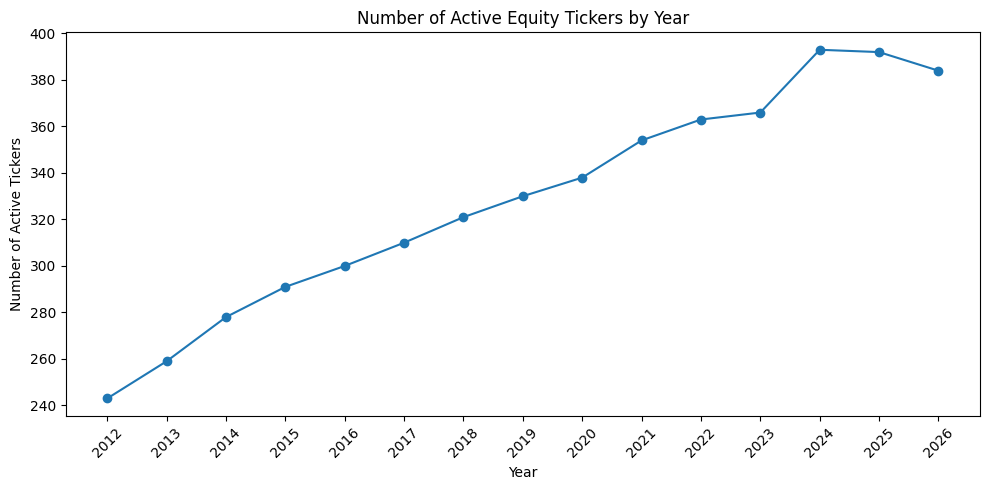

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    active_tickers_by_year["Year"],
    active_tickers_by_year["Active_Tickers"],
    marker="o"
)

plt.title("Number of Active Equity Tickers by Year")
plt.xlabel("Year")
plt.ylabel("Number of Active Tickers")
plt.xticks(active_tickers_by_year["Year"], rotation=45)
plt.tight_layout()
plt.show()

In [100]:
records_by_year = (
    master_df.groupby("Year")
    .size()
    .reset_index(name="Trading_Records")
)

records_by_year

,Year,Trading_Records
0,2012,13512
1,2013,57852
2,2014,62063
3,2015,68538
4,2016,70306
5,2017,74799
6,2018,75123
7,2019,76609
8,2020,66339
9,2021,81811


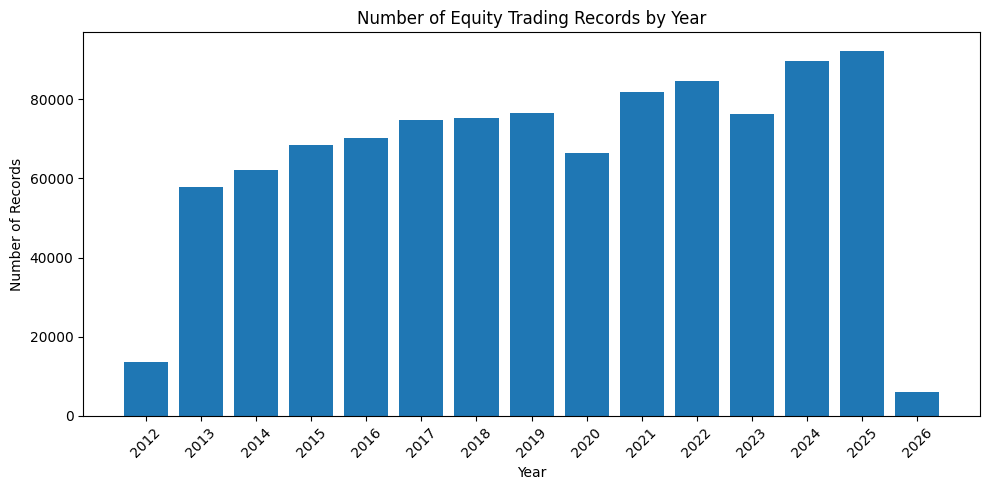

In [101]:
plt.figure(figsize=(10, 5))

plt.bar(
    records_by_year["Year"],
    records_by_year["Trading_Records"]
)

plt.title("Number of Equity Trading Records by Year")
plt.xlabel("Year")
plt.ylabel("Number of Records")
plt.xticks(records_by_year["Year"], rotation=45)
plt.tight_layout()
plt.show()

In [102]:
ticker_coverage = (
    master_df.groupby("Ticker")
    .agg(
        First_Date=("Date", "min"),
        Last_Date=("Date", "max"),
        Trading_Days=("Date", "count")
    )
    .reset_index()
)

ticker_coverage.head()

,Ticker,First_Date,Last_Date,Trading_Days
0,AAMRANET,2017-10-02,2026-01-22,1954
1,AAMRATECH,2012-10-01,2026-01-22,3153
2,ABBANK,2012-10-01,2026-01-22,3149
3,ACFL,2018-08-06,2026-01-22,1668
4,ACHIASF,2024-01-28,2026-01-22,467


In [103]:
ticker_coverage.sort_values(
    "Trading_Days",
    ascending=False
).head(10)

,Ticker,First_Date,Last_Date,Trading_Days
60,BDWELDING,2012-10-01,2026-01-22,3166
282,PRIMEBANK,2012-10-01,2026-01-22,3159
258,OLYMPIC,2012-10-01,2026-01-22,3159
354,SQURPHARMA,2012-10-01,2026-01-22,3159
116,EHL,2012-10-01,2026-01-22,3159
290,PUBALIBANK,2012-10-01,2026-01-22,3158
278,PREMIERBAN,2012-10-01,2026-01-22,3157
183,JAMUNAOIL,2012-10-01,2026-01-22,3157
381,UTTARABANK,2012-10-01,2026-01-22,3157
54,BDCOM,2012-10-01,2026-01-22,3157


In [104]:
ticker_coverage.sort_values(
    "Trading_Days",
    ascending=True
).head(10)

,Ticker,First_Date,Last_Date,Trading_Days
45,BANKASI1PB,2024-01-15,2025-06-23,5
391,YUSUFLOUR,2024-01-30,2025-12-28,87
331,SHARPIND,2024-10-29,2026-01-22,296
365,TECHNODRUG,2024-07-14,2026-01-22,364
90,CRAFTSMAN,2024-05-16,2026-01-22,399
157,HIMADRI,2024-01-28,2026-01-22,431
389,WONDERTOYS,2024-01-28,2026-01-22,436
387,WEBCOATS,2024-03-11,2026-01-22,438
40,ASIATICLAB,2024-03-06,2026-01-22,444
63,BENGALBISC,2024-01-28,2026-01-22,447


## Market Coverage Analysis

The number of available equity securities varies over time because
companies have different listing periods and historical data coverage.

Therefore, comparisons across stocks should consider differences in
observation periods rather than assuming that all securities have the
same amount of historical data.

**EDA Step 2 — Trading Activity Analysis**

In [105]:
trading_activity = (
    master_df.groupby("Ticker")
    .agg(
        Total_Volume=("Volume", "sum"),
        Average_Daily_Volume=("Volume", "mean"),
        Median_Daily_Volume=("Volume", "median"),
        Trading_Days=("Date", "count")
    )
    .reset_index()
)

trading_activity.head()

,Ticker,Total_Volume,Average_Daily_Volume,Median_Daily_Volume,Trading_Days
0,AAMRANET,1052157156,"538,463.23","267,445.50",1954
1,AAMRATECH,1738033310,"551,231.62","236,953.00",3153
2,ABBANK,4716149579,"1,497,665.79","616,176.00",3149
3,ACFL,455035130,"272,802.84","133,959.00",1668
4,ACHIASF,76194840,"163,158.12","81,012.00",467


In [106]:
top_total_volume = trading_activity.sort_values(
    "Total_Volume",
    ascending=False
).head(10)

top_total_volume

,Ticker,Total_Volume,Average_Daily_Volume,Median_Daily_Volume,Trading_Days
171,IFIC,11298802847,"3,583,508.67","1,182,759.00",3153
67,BEXIMCO,10718491029,"3,555,055.07","1,529,075.00",3015
241,NBL,9353163741,"3,029,855.44","1,635,526.00",3087
193,KEYACOSMET,8447712892,"2,676,715.11","1,119,760.50",3156
199,LANKABAFIN,6695846996,"2,136,517.87","912,959.00",3134
141,GENNEXT,6498460735,"2,092,228.18","1,198,689.00",3106
19,ALIF,5965512912,"1,913,249.81","835,135.50",3118
259,ONEBANKPLC,5754696113,"1,826,887.65","873,000.00",3150
278,PREMIERBAN,5617028905,"1,779,229.94","859,845.00",3157
134,FIRSTSBANK,5474421380,"1,767,082.43","699,262.00",3098


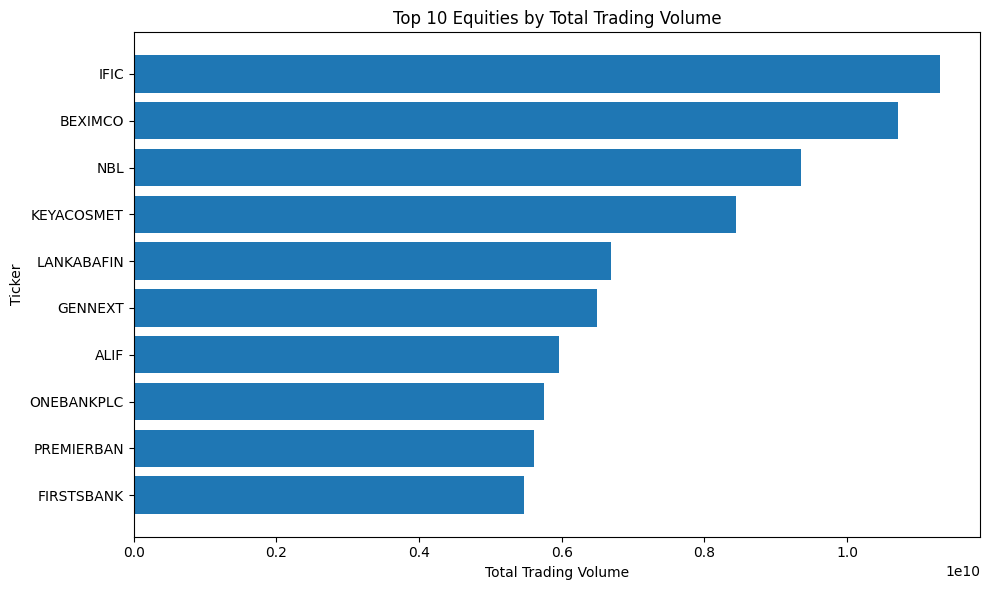

In [107]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_total_volume["Ticker"],
    top_total_volume["Total_Volume"]
)

plt.title("Top 10 Equities by Total Trading Volume")
plt.xlabel("Total Trading Volume")
plt.ylabel("Ticker")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [108]:
top_avg_volume = trading_activity.sort_values(
    "Average_Daily_Volume",
    ascending=False
).head(10)

top_avg_volume

,Ticker,Total_Volume,Average_Daily_Volume,Median_Daily_Volume,Trading_Days
171,IFIC,11298802847,"3,583,508.67","1,182,759.00",3153
67,BEXIMCO,10718491029,"3,555,055.07","1,529,075.00",3015
251,NRBBANK,1551901777,"3,448,670.62","2,351,813.00",450
241,NBL,9353163741,"3,029,855.44","1,635,526.00",3087
193,KEYACOSMET,8447712892,"2,676,715.11","1,119,760.50",3156
223,MIDLANDBNK,1604734831,"2,387,998.26","1,756,964.50",672
308,ROBI,2685454264,"2,212,071.06","921,866.50",1214
199,LANKABAFIN,6695846996,"2,136,517.87","912,959.00",3134
141,GENNEXT,6498460735,"2,092,228.18","1,198,689.00",3106
107,DSSL,4553333865,"2,013,858.41","1,166,138.00",2261


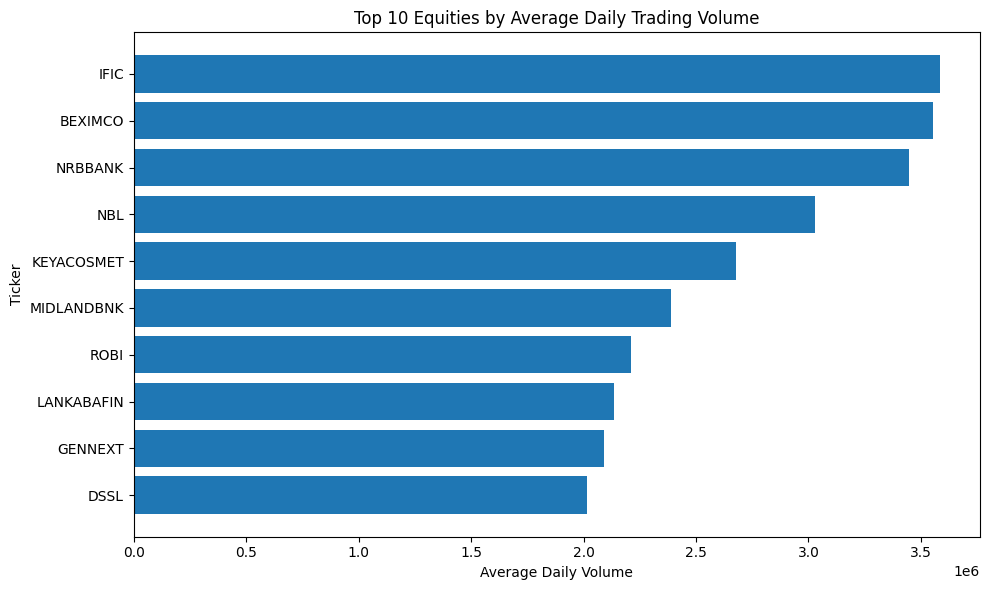

In [109]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_avg_volume["Ticker"],
    top_avg_volume["Average_Daily_Volume"]
)

plt.title("Top 10 Equities by Average Daily Trading Volume")
plt.xlabel("Average Daily Volume")
plt.ylabel("Ticker")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [110]:
comparison = trading_activity[
    [
        "Ticker",
        "Total_Volume",
        "Average_Daily_Volume",
        "Trading_Days"
    ]
].sort_values(
    "Average_Daily_Volume",
    ascending=False
).head(15)

comparison

,Ticker,Total_Volume,Average_Daily_Volume,Trading_Days
171,IFIC,11298802847,"3,583,508.67",3153
67,BEXIMCO,10718491029,"3,555,055.07",3015
251,NRBBANK,1551901777,"3,448,670.62",450
241,NBL,9353163741,"3,029,855.44",3087
193,KEYACOSMET,8447712892,"2,676,715.11",3156
223,MIDLANDBNK,1604734831,"2,387,998.26",672
308,ROBI,2685454264,"2,212,071.06",1214
199,LANKABAFIN,6695846996,"2,136,517.87",3134
141,GENNEXT,6498460735,"2,092,228.18",3106
107,DSSL,4553333865,"2,013,858.41",2261


**A stock may rank highly in total volume simply because it has a longer trading history. Average daily volume provides a more comparable measure of typical trading activity across securities with different coverage periods.**

In [111]:
yearly_volume = (
    master_df.groupby("Year")["Volume"]
    .sum()
    .reset_index()
)

yearly_volume

,Year,Volume
0,2012,3607808140
1,2013,18390535090
2,2014,23011029697
3,2015,22224112595
4,2016,31516491089
5,2017,60066412286
6,2018,31292549795
7,2019,29684868611
8,2020,41575062341
9,2021,91808046052


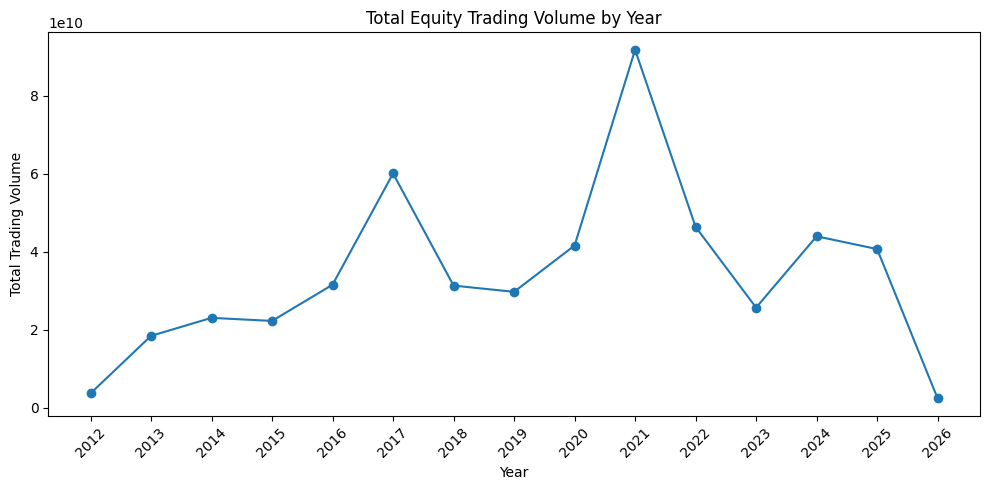

In [112]:
plt.figure(figsize=(10, 5))

plt.plot(
    yearly_volume["Year"],
    yearly_volume["Volume"],
    marker="o"
)

plt.title("Total Equity Trading Volume by Year")
plt.xlabel("Year")
plt.ylabel("Total Trading Volume")
plt.xticks(yearly_volume["Year"], rotation=45)
plt.tight_layout()
plt.show()

## Trading Activity Analysis

Trading activity was evaluated using both total and average daily volume.

Total trading volume may favor securities with longer historical coverage,
while average daily volume provides a more comparable view of typical
trading activity across equities.

The yearly volume trend should also be interpreted carefully because the
2026 dataset contains only a partial year.

**EDA Step 3 — Price Trend Analysis:**



In [113]:
median_trading_days = trading_activity["Trading_Days"].median()

eligible_tickers = trading_activity[
    trading_activity["Trading_Days"] >= median_trading_days
]

selected_tickers = (
    eligible_tickers
    .sort_values("Average_Daily_Volume", ascending=False)
    .head(5)["Ticker"]
    .tolist()
)

selected_tickers

['IFIC', 'BEXIMCO', 'NBL', 'KEYACOSMET', 'LANKABAFIN']

In [114]:
trading_activity[
    trading_activity["Ticker"].isin(selected_tickers)
].sort_values(
    "Average_Daily_Volume",
    ascending=False
)

,Ticker,Total_Volume,Average_Daily_Volume,Median_Daily_Volume,Trading_Days
171,IFIC,11298802847,"3,583,508.67","1,182,759.00",3153
67,BEXIMCO,10718491029,"3,555,055.07","1,529,075.00",3015
241,NBL,9353163741,"3,029,855.44","1,635,526.00",3087
193,KEYACOSMET,8447712892,"2,676,715.11","1,119,760.50",3156
199,LANKABAFIN,6695846996,"2,136,517.87","912,959.00",3134


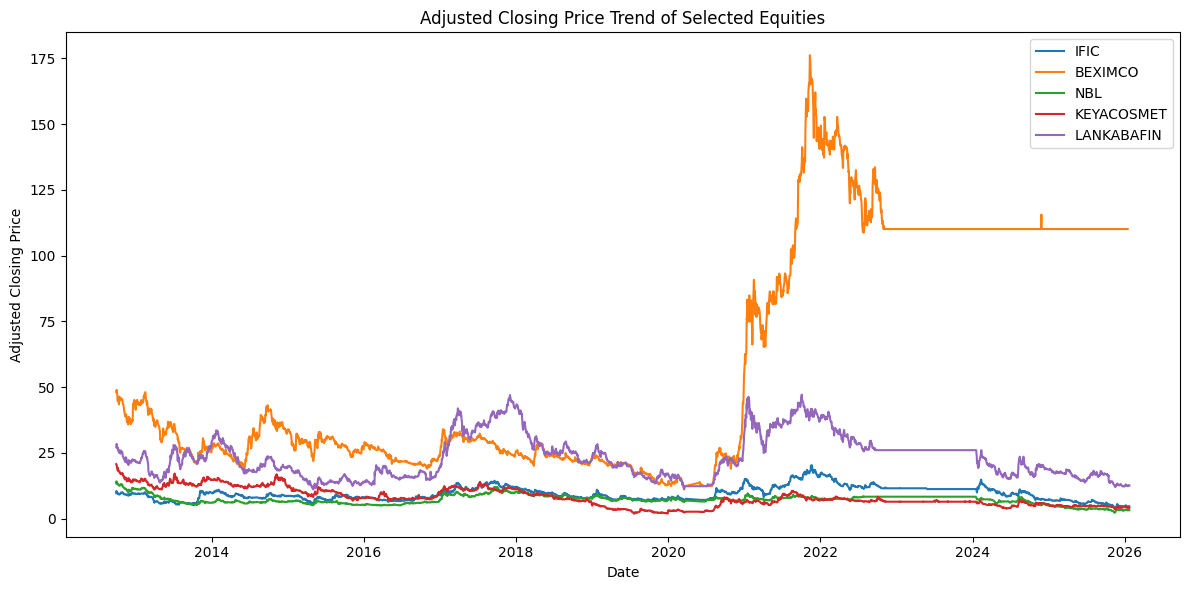

In [115]:
selected_data = master_df[
    master_df["Ticker"].isin(selected_tickers)
].copy()

plt.figure(figsize=(12, 6))

for ticker in selected_tickers:
    temp = selected_data[
        selected_data["Ticker"] == ticker
    ]

    plt.plot(
        temp["Date"],
        temp["Close"],
        label=ticker
    )

plt.title("Adjusted Closing Price Trend of Selected Equities")
plt.xlabel("Date")
plt.ylabel("Adjusted Closing Price")
plt.legend()
plt.tight_layout()
plt.show()

In [116]:
normalized_data = selected_data[
    ["Date", "Ticker", "Close"]
].copy()

normalized_data["Normalized_Price"] = (
    normalized_data.groupby("Ticker")["Close"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

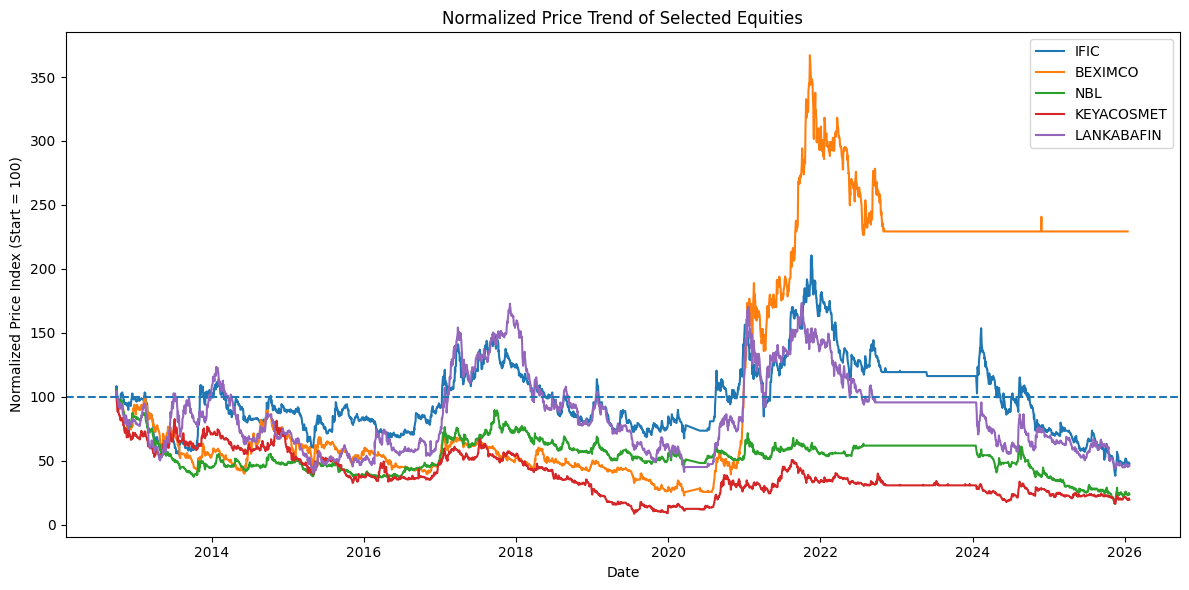

In [117]:
plt.figure(figsize=(12, 6))

for ticker in selected_tickers:
    temp = normalized_data[
        normalized_data["Ticker"] == ticker
    ]

    plt.plot(
        temp["Date"],
        temp["Normalized_Price"],
        label=ticker
    )

plt.axhline(100, linestyle="--")

plt.title("Normalized Price Trend of Selected Equities")
plt.xlabel("Date")
plt.ylabel("Normalized Price Index (Start = 100)")
plt.legend()
plt.tight_layout()
plt.show()

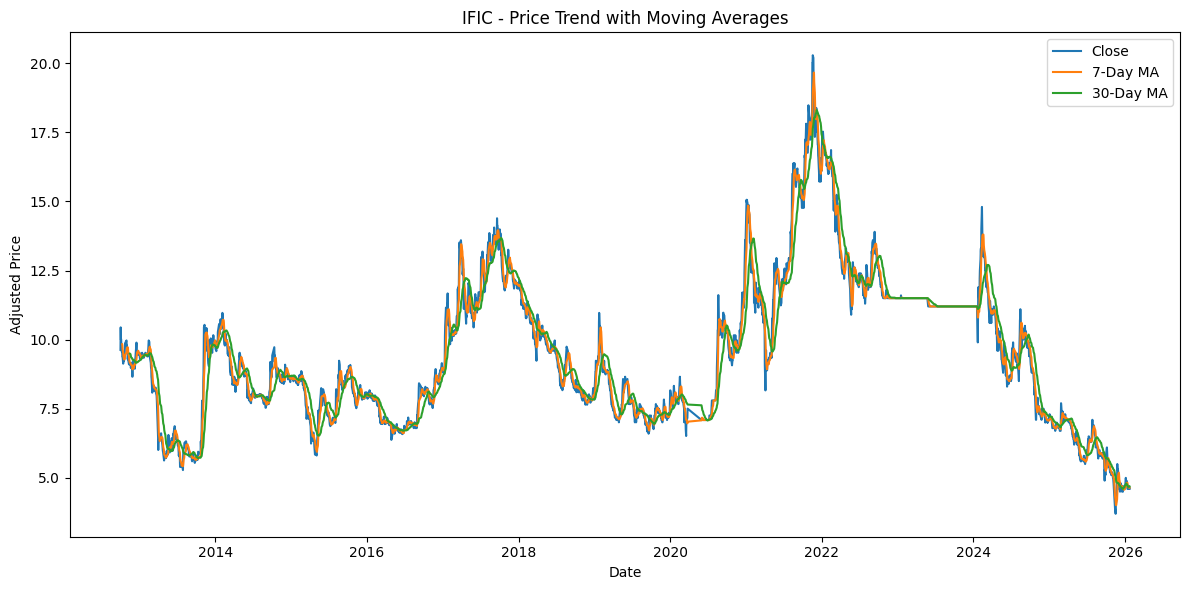

In [118]:
focus_ticker = selected_tickers[0]

focus_data = master_df[
    master_df["Ticker"] == focus_ticker
].copy()

plt.figure(figsize=(12, 6))

plt.plot(
    focus_data["Date"],
    focus_data["Close"],
    label="Close"
)

plt.plot(
    focus_data["Date"],
    focus_data["MA_7"],
    label="7-Day MA"
)

plt.plot(
    focus_data["Date"],
    focus_data["MA_30"],
    label="30-Day MA"
)

plt.title(f"{focus_ticker} - Price Trend with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Adjusted Price")
plt.legend()
plt.tight_layout()
plt.show()

## Price Trend Analysis

Selected equities were chosen based on trading activity while requiring
at least median historical coverage to reduce the influence of securities
with very short observation periods.

Raw adjusted closing prices were examined alongside normalized price
indices. Normalization allows securities with different absolute price
levels to be compared on a common starting basis.

Short-term and longer-term price movements were also examined using
7-day and 30-day moving averages.

# **EDA Step 4 —** Return Analysis: average/median return, cumulative return, return distribution, positive vs negative trading days & selected stocks comparison

In [119]:
master_df["Daily_Return_Pct"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

,Daily_Return_Pct
count,"995,511.00"
mean,0.04
std,4.42
min,-99.29
1%,-6.91
5%,-3.75
25%,-1.30
50%,0.00
75%,0.97
95%,4.88


In [120]:
return_summary = (
    master_df.groupby("Ticker")
    .agg(
        Average_Daily_Return=("Daily_Return_Pct", "mean"),
        Median_Daily_Return=("Daily_Return_Pct", "median"),
        Return_Std=("Daily_Return_Pct", "std"),
        Min_Daily_Return=("Daily_Return_Pct", "min"),
        Max_Daily_Return=("Daily_Return_Pct", "max")
    )
    .reset_index()
)

return_summary.head()

,Ticker,Average_Daily_Return,Median_Daily_Return,Return_Std,Min_Daily_Return,Max_Daily_Return
0,AAMRANET,-0.06,-0.26,2.64,-11.55,16.96
1,AAMRATECH,-0.01,-0.26,2.50,-9.96,10.47
2,ABBANK,-0.03,0.00,2.32,-22.58,10.00
3,ACFL,-0.05,0.00,2.68,-9.92,15.43
4,ACHIASF,0.19,0.00,3.12,-9.91,10.00


In [121]:
selected_return_summary = return_summary[
    return_summary["Ticker"].isin(selected_tickers)
].copy()

selected_return_summary

,Ticker,Average_Daily_Return,Median_Daily_Return,Return_Std,Min_Daily_Return,Max_Daily_Return
67,BEXIMCO,0.06,0.00,2.36,-12.60,11.21
171,IFIC,0.00,0.00,2.23,-12.28,10.26
193,KEYACOSMET,-0.01,0.00,3.02,-24.24,63.16
199,LANKABAFIN,0.01,0.00,2.63,-15.62,35.42
241,NBL,-0.03,0.00,2.01,-11.21,10.00


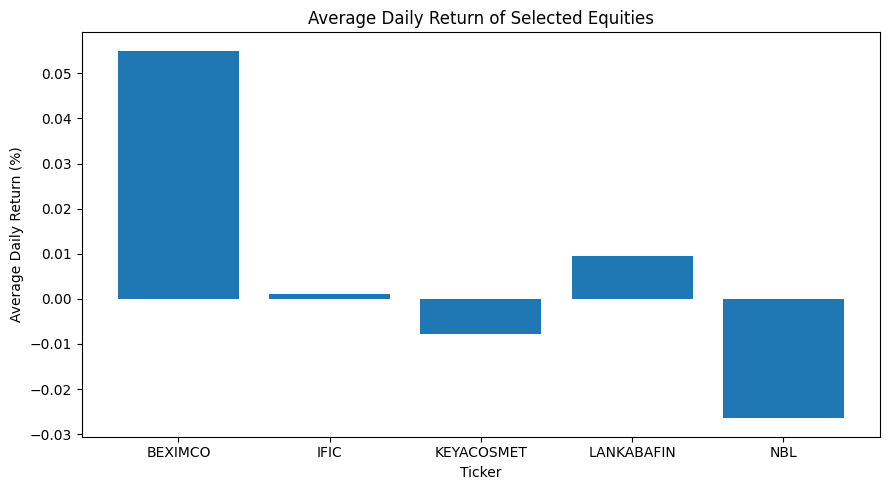

In [122]:
plt.figure(figsize=(9, 5))

plt.bar(
    selected_return_summary["Ticker"],
    selected_return_summary["Average_Daily_Return"]
)

plt.title("Average Daily Return of Selected Equities")
plt.xlabel("Ticker")
plt.ylabel("Average Daily Return (%)")
plt.tight_layout()
plt.show()

In [123]:
master_df["Positive_Day"] = master_df["Daily_Return_Pct"] > 0
master_df["Negative_Day"] = master_df["Daily_Return_Pct"] < 0

In [124]:
return_direction = (
    master_df.dropna(subset=["Daily_Return_Pct"])
    .groupby("Ticker")
    .agg(
        Positive_Days=("Positive_Day", "sum"),
        Negative_Days=("Negative_Day", "sum"),
        Total_Return_Days=("Daily_Return_Pct", "count")
    )
    .reset_index()
)

return_direction["Positive_Day_Pct"] = (
    return_direction["Positive_Days"]
    / return_direction["Total_Return_Days"]
    * 100
)

return_direction["Negative_Day_Pct"] = (
    return_direction["Negative_Days"]
    / return_direction["Total_Return_Days"]
    * 100
)

In [125]:
return_direction[
    return_direction["Ticker"].isin(selected_tickers)
]

,Ticker,Positive_Days,Negative_Days,Total_Return_Days,Positive_Day_Pct,Negative_Day_Pct
67,BEXIMCO,918,1274,3014,30.46,42.27
171,IFIC,1011,1330,3152,32.07,42.20
193,KEYACOSMET,868,1284,3155,27.51,40.70
199,LANKABAFIN,1115,1463,3133,35.59,46.70
241,NBL,789,1059,3086,25.57,34.32


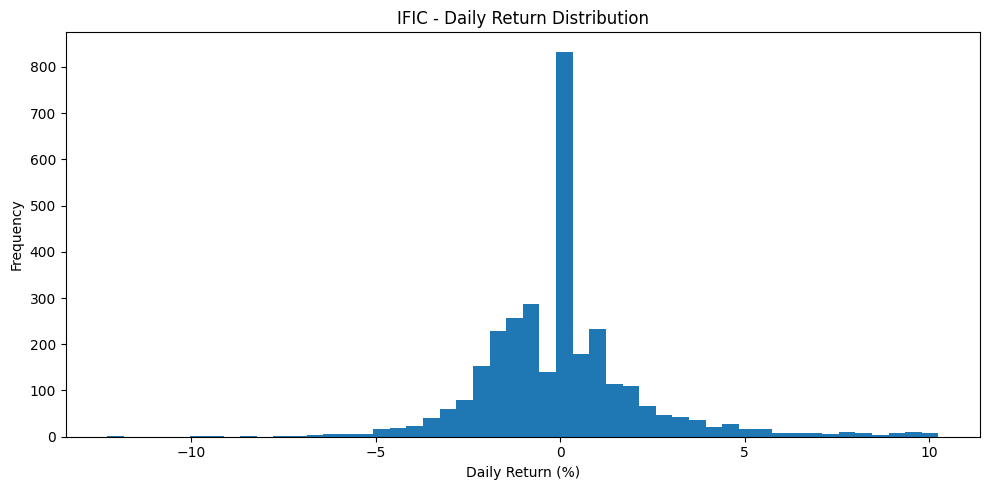

In [126]:
focus_returns = master_df[
    master_df["Ticker"] == focus_ticker
]["Daily_Return_Pct"].dropna()

plt.figure(figsize=(10, 5))

plt.hist(
    focus_returns,
    bins=50
)

plt.title(f"{focus_ticker} - Daily Return Distribution")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [127]:
master_df["Cumulative_Return_Pct"] = (
    (
        1 + master_df["Daily_Return_Pct"] / 100
    )
    .groupby(master_df["Ticker"])
    .cumprod()
    - 1
) * 100

In [128]:
master_df[
    [
        "Date",
        "Ticker",
        "Close",
        "Daily_Return_Pct",
        "Cumulative_Return_Pct"
    ]
].head(20)

,Date,Ticker,Close,Daily_Return_Pct,Cumulative_Return_Pct
0,2017-10-02,AAMRANET,114.76,NaN,NaN
1,2017-10-03,AAMRANET,105.77,-7.83,-7.83
2,2017-10-04,AAMRANET,116.31,9.96,1.35
3,2017-10-05,AAMRANET,118.03,1.47,2.85
4,2017-10-08,AAMRANET,111.08,-5.88,-3.20
5,2017-10-09,AAMRANET,114.76,3.31,-0.00
6,2017-10-10,AAMRANET,107.08,-6.69,-6.69
7,2017-10-11,AAMRANET,99.81,-6.79,-13.02
8,2017-10-12,AAMRANET,94.01,-5.81,-18.08
9,2017-10-15,AAMRANET,87.56,-6.86,-23.70


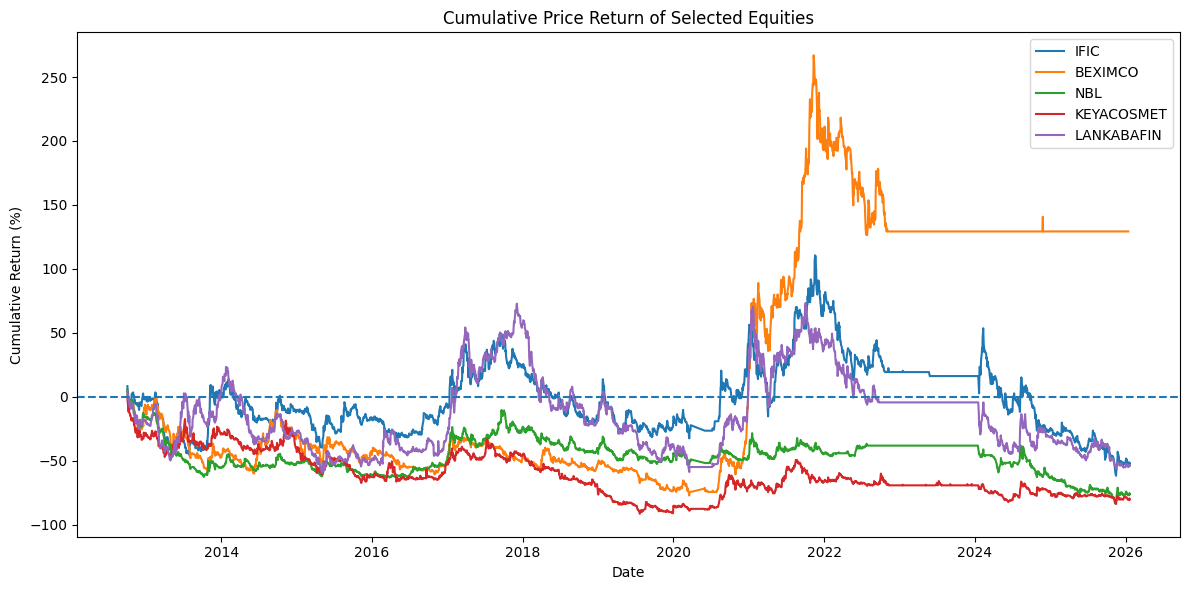

In [129]:
plt.figure(figsize=(12, 6))

for ticker in selected_tickers:
    temp = master_df[
        master_df["Ticker"] == ticker
    ]

    plt.plot(
        temp["Date"],
        temp["Cumulative_Return_Pct"],
        label=ticker
    )

plt.axhline(0, linestyle="--")

plt.title("Cumulative Price Return of Selected Equities")
plt.xlabel("Date")
plt.ylabel("Cumulative Return (%)")
plt.legend()
plt.tight_layout()
plt.show()

## Return Analysis

Daily percentage returns were analyzed to evaluate historical price
movements independently of absolute stock-price levels.

Average and median daily returns, return dispersion, positive and
negative trading days, and cumulative compounded price returns were
examined.

Cumulative return comparisons should be interpreted cautiously because
different securities may have different starting dates and historical
coverage periods.

# **EDA Step 5 — Volatility Analysis**

In [130]:
volatility_summary = (
    master_df.groupby("Ticker")
    .agg(
        Average_30D_Volatility=("Volatility_30", "mean"),
        Median_30D_Volatility=("Volatility_30", "median"),
        Max_30D_Volatility=("Volatility_30", "max")
    )
    .reset_index()
)

volatility_summary.head()

,Ticker,Average_30D_Volatility,Median_30D_Volatility,Max_30D_Volatility
0,AAMRANET,2.49,2.35,5.09
1,AAMRATECH,2.32,2.18,5.80
2,ABBANK,2.03,1.95,4.81
3,ACFL,2.34,2.40,5.30
4,ACHIASF,3.08,3.17,5.50


In [131]:
top_volatile = (
    volatility_summary
    .sort_values("Average_30D_Volatility", ascending=False)
    .head(10)
)

top_volatile

,Ticker,Average_30D_Volatility,Median_30D_Volatility,Max_30D_Volatility
271,PHOENIXFIN,14.15,2.38,383.41
391,YUSUFLOUR,9.72,10.56,11.71
88,CONTININS,8.97,2.45,261.47
157,HIMADRI,6.47,6.52,9.41
389,WONDERTOYS,6.00,6.20,8.15
314,SADHESIVE,4.65,4.37,8.03
57,BDPAINTS,4.61,4.54,6.83
63,BENGALBISC,4.43,4.46,6.34
325,SAVAREFR,4.33,4.31,7.28
90,CRAFTSMAN,4.31,4.11,6.50


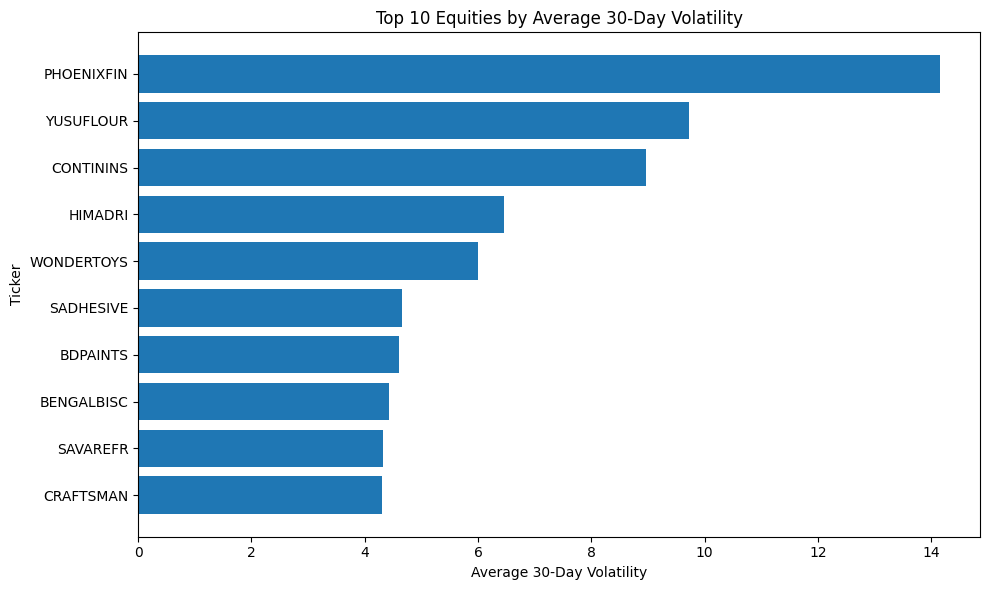

In [132]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_volatile["Ticker"],
    top_volatile["Average_30D_Volatility"]
)

plt.title("Top 10 Equities by Average 30-Day Volatility")
plt.xlabel("Average 30-Day Volatility")
plt.ylabel("Ticker")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [133]:
selected_volatility = volatility_summary[
    volatility_summary["Ticker"].isin(selected_tickers)
]

selected_volatility

,Ticker,Average_30D_Volatility,Median_30D_Volatility,Max_30D_Volatility
67,BEXIMCO,1.91,1.83,6.22
171,IFIC,1.99,1.97,4.79
193,KEYACOSMET,2.60,2.33,12.07
199,LANKABAFIN,2.29,2.25,7.61
241,NBL,1.74,1.64,5.72


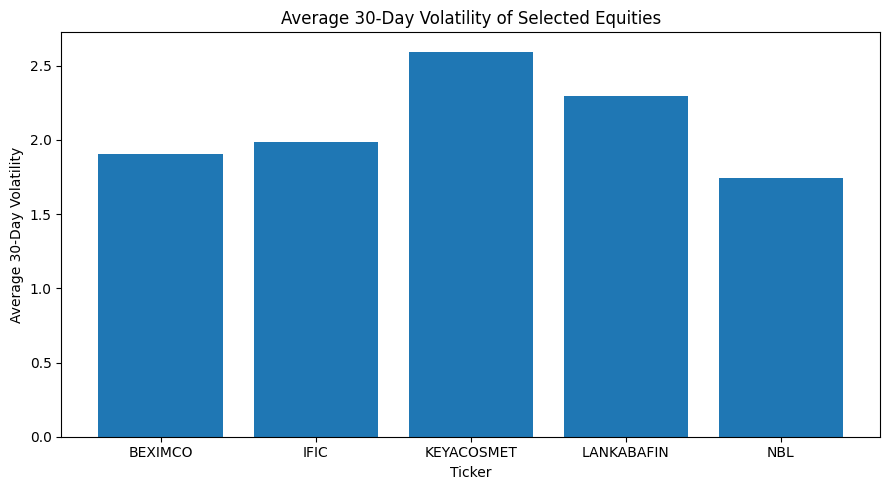

In [134]:
plt.figure(figsize=(9, 5))

plt.bar(
    selected_volatility["Ticker"],
    selected_volatility["Average_30D_Volatility"]
)

plt.title("Average 30-Day Volatility of Selected Equities")
plt.xlabel("Ticker")
plt.ylabel("Average 30-Day Volatility")
plt.tight_layout()
plt.show()

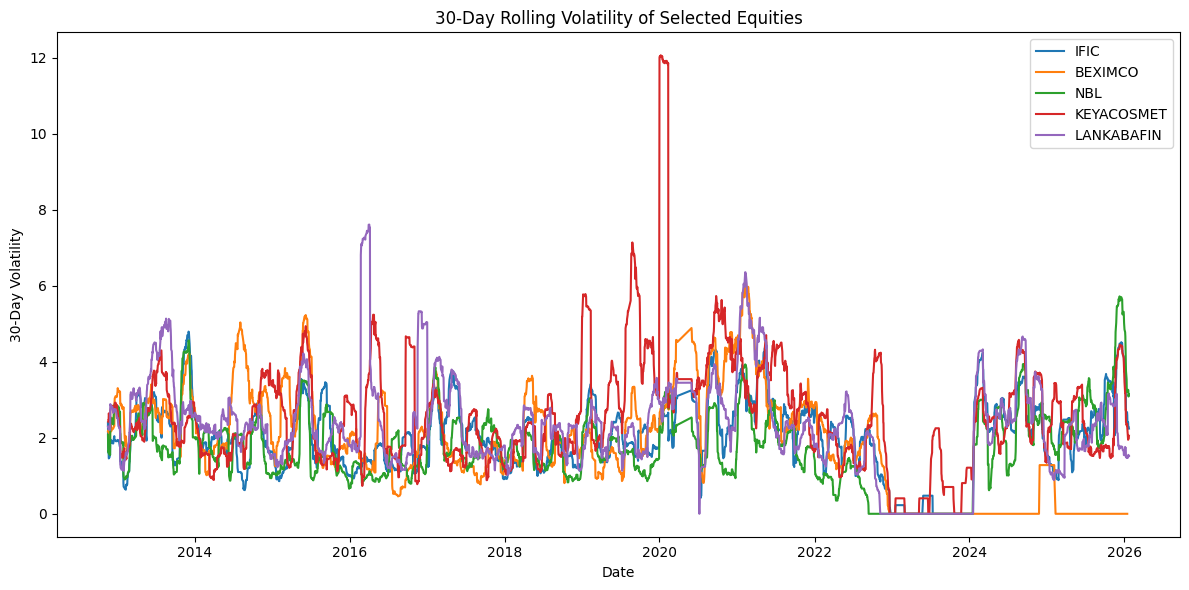

In [135]:
plt.figure(figsize=(12, 6))

for ticker in selected_tickers:
    temp = master_df[
        master_df["Ticker"] == ticker
    ]

    plt.plot(
        temp["Date"],
        temp["Volatility_30"],
        label=ticker
    )

plt.title("30-Day Rolling Volatility of Selected Equities")
plt.xlabel("Date")
plt.ylabel("30-Day Volatility")
plt.legend()
plt.tight_layout()
plt.show()

In [136]:
yearly_volatility = (
    master_df.groupby("Year")["Daily_Return_Pct"]
    .std()
    .reset_index(name="Market_Return_Std")
)

yearly_volatility

,Year,Market_Return_Std
0,2012,2.82
1,2013,3.09
2,2014,3.93
3,2015,2.61
4,2016,2.49
5,2017,2.22
6,2018,2.62
7,2019,8.55
8,2020,10.27
9,2021,3.37


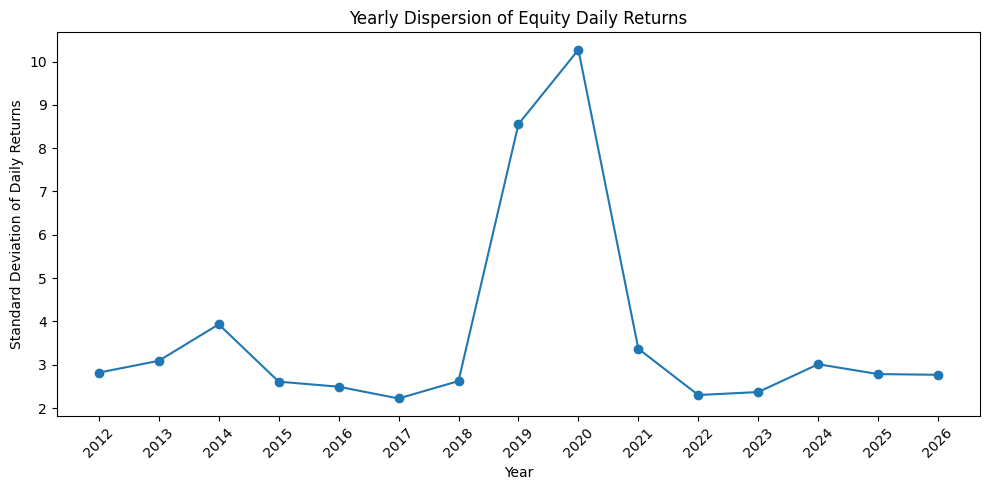

In [137]:
plt.figure(figsize=(10, 5))

plt.plot(
    yearly_volatility["Year"],
    yearly_volatility["Market_Return_Std"],
    marker="o"
)

plt.title("Yearly Dispersion of Equity Daily Returns")
plt.xlabel("Year")
plt.ylabel("Standard Deviation of Daily Returns")
plt.xticks(yearly_volatility["Year"], rotation=45)
plt.tight_layout()
plt.show()

In [138]:
master_df.nlargest(
    20,
    "Volatility_30"
)[
    [
        "Date",
        "Ticker",
        "Daily_Return_Pct",
        "Volatility_30"
    ]
]

,Date,Ticker,Daily_Return_Pct,Volatility_30
686501,2020-01-09,PHOENIXFIN,0.47,383.41
686502,2020-01-12,PHOENIXFIN,-0.46,383.15
686495,2020-01-01,PHOENIXFIN,"2,050.00",383.05
686496,2020-01-02,PHOENIXFIN,0.00,383.05
686497,2020-01-05,PHOENIXFIN,0.00,383.05
686498,2020-01-06,PHOENIXFIN,0.00,383.05
686499,2020-01-07,PHOENIXFIN,0.00,383.05
686500,2020-01-08,PHOENIXFIN,0.00,383.05
686503,2020-01-13,PHOENIXFIN,0.00,383.01
686504,2020-01-14,PHOENIXFIN,-3.72,382.87


## Volatility Analysis

Historical variability was evaluated using 30-day rolling standard
deviation of daily returns.

This analysis highlights periods and securities with comparatively
higher return variability. Volatility is interpreted as a descriptive
measure of historical price movement rather than as a prediction of
future performance.

Year-level return dispersion was also examined to identify periods in
which equity price movements were more variable across the dataset.

# **EDA Step 6 — Volume vs Price Movement Analysis:**

In [139]:
import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [140]:
dataset_path = "/content/drive/MyDrive/DSE_Market_Analysis"
full_raw_path = dataset_path + "/Full Raw Data"
metadata_path = dataset_path + "/metadata"

In [141]:
adjusted_df = pd.read_csv(full_raw_path + "/Adjusted.csv")
unadjusted_df = pd.read_csv(full_raw_path + "/UnAdjusted.csv")
metadata = pd.read_csv(metadata_path + "/company_metadata.csv")

In [142]:
adjusted_df["Date"] = pd.to_datetime(adjusted_df["Date"])
unadjusted_df["Date"] = pd.to_datetime(unadjusted_df["Date"])

In [143]:
equity_tickers = metadata.loc[
    metadata["Instrument_Type"] == "Equity",
    "Ticker"
]

In [144]:
equity_adjusted = adjusted_df[
    adjusted_df["Ticker"].isin(equity_tickers)
].copy()

equity_unadjusted = unadjusted_df[
    unadjusted_df["Ticker"].isin(equity_tickers)
].copy()

In [145]:
adjusted_master = equity_adjusted[
    ["Date", "Ticker", "Open", "High", "Low", "Close"]
].copy()

volume_master = equity_unadjusted[
    ["Date", "Ticker", "Volume"]
].copy()

master_df = adjusted_master.merge(
    volume_master,
    on=["Date", "Ticker"],
    how="inner"
)

master_df = master_df.sort_values(
    ["Ticker", "Date"]
).reset_index(drop=True)

In [146]:
master_df["Daily_Return_Pct"] = (
    master_df.groupby("Ticker")["Close"]
    .pct_change(fill_method=None)
    * 100
)

master_df["Price_Change"] = (
    master_df["Close"] - master_df["Open"]
)

master_df["Price_Change_Pct"] = (
    (master_df["Close"] - master_df["Open"])
    / master_df["Open"]
    * 100
)

master_df["Trading_Range"] = (
    master_df["High"] - master_df["Low"]
)

master_df["Trading_Range_Pct"] = (
    (master_df["High"] - master_df["Low"])
    / master_df["Open"]
    * 100
)

master_df["MA_7"] = (
    master_df.groupby("Ticker")["Close"]
    .transform(lambda x: x.rolling(7).mean())
)

master_df["MA_30"] = (
    master_df.groupby("Ticker")["Close"]
    .transform(lambda x: x.rolling(30).mean())
)

master_df["Volatility_30"] = (
    master_df.groupby("Ticker")["Daily_Return_Pct"]
    .transform(lambda x: x.rolling(30).std())
)

master_df["Volume_Change_Pct"] = (
    master_df.groupby("Ticker")["Volume"]
    .pct_change(fill_method=None)
    * 100
)

master_df.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

master_df["Year"] = master_df["Date"].dt.year

In [147]:
master_df.head()

,Date,Ticker,Open,High,Low,Close,Volume,Daily_Return_Pct,Price_Change,Price_Change_Pct,Trading_Range,Trading_Range_Pct,MA_7,MA_30,Volatility_30,Volume_Change_Pct,Year
0,2017-10-02,AAMRANET,66.24,122.52,66.24,114.76,5693595,NaN,48.52,73.24,56.28,84.96,NaN,NaN,NaN,NaN,2017
1,2017-10-03,AAMRANET,114.35,120.07,104.47,105.77,962089,-7.83,-8.58,-7.50,15.60,13.64,NaN,NaN,NaN,-83.10,2017
2,2017-10-04,AAMRANET,102.92,116.31,102.18,116.31,2367700,9.96,13.40,13.02,14.13,13.73,NaN,NaN,NaN,146.10,2017
3,2017-10-05,AAMRANET,118.52,127.91,116.80,118.03,2052356,1.47,-0.49,-0.41,11.11,9.37,NaN,NaN,NaN,-13.32,2017
4,2017-10-08,AAMRANET,117.62,121.29,109.45,111.08,2246879,-5.88,-6.53,-5.56,11.84,10.07,NaN,NaN,NaN,9.48,2017


In [148]:
master_df.shape

(995906, 17)

In [149]:
master_df["Abs_Daily_Return_Pct"] = (
    master_df["Daily_Return_Pct"].abs()
)

In [150]:
master_df[
    ["Date", "Ticker", "Daily_Return_Pct", "Abs_Daily_Return_Pct"]
].head()

,Date,Ticker,Daily_Return_Pct,Abs_Daily_Return_Pct
0,2017-10-02,AAMRANET,NaN,NaN
1,2017-10-03,AAMRANET,-7.83,7.83
2,2017-10-04,AAMRANET,9.96,9.96
3,2017-10-05,AAMRANET,1.47,1.47
4,2017-10-08,AAMRANET,-5.88,5.88


In [151]:
master_df["Abs_Daily_Return_Pct"] = master_df["Daily_Return_Pct"].abs()

In [152]:
selected_common = master_df[
    master_df["Ticker"].isin(selected_tickers)
].copy()

common_start = (
    selected_common.groupby("Ticker")["Date"]
    .min()
    .max()
)

common_end = (
    selected_common.groupby("Ticker")["Date"]
    .max()
    .min()
)

print("Common Start Date:", common_start)
print("Common End Date:", common_end)

Common Start Date: 2012-10-01 00:00:00
Common End Date: 2026-01-14 00:00:00


In [154]:
selected_common = master_df[
    master_df["Ticker"].isin(selected_tickers)
].copy()

In [155]:
common_start = (
    selected_common.groupby("Ticker")["Date"]
    .min()
    .max()
)

common_end = (
    selected_common.groupby("Ticker")["Date"]
    .max()
    .min()
)

print("Common Start Date:", common_start)
print("Common End Date:", common_end)

Common Start Date: 2012-10-01 00:00:00
Common End Date: 2026-01-14 00:00:00


In [156]:
common_window_df = selected_common[
    (selected_common["Date"] >= common_start) &
    (selected_common["Date"] <= common_end)
].copy()

common_window_df = common_window_df.sort_values(
    ["Ticker", "Date"]
).reset_index(drop=True)

In [157]:
common_window_df.head()

,Date,Ticker,Open,High,Low,Close,Volume,Daily_Return_Pct,Price_Change,Price_Change_Pct,Trading_Range,Trading_Range_Pct,MA_7,MA_30,Volatility_30,Volume_Change_Pct,Year,Abs_Daily_Return_Pct
0,2012-10-01,BEXIMCO,48.01,49.04,46.64,48.01,1949700,NaN,0.00,0.00,2.40,5.00,NaN,NaN,NaN,NaN,2012,NaN
1,2012-10-02,BEXIMCO,49.24,50.07,48.63,48.90,1845600,1.86,-0.34,-0.70,1.44,2.92,NaN,NaN,NaN,-5.34,2012,1.86
2,2012-10-03,BEXIMCO,50.68,51.03,48.63,48.90,3296700,0.00,-1.78,-3.52,2.40,4.74,NaN,NaN,NaN,78.62,2012,0.00
3,2012-10-04,BEXIMCO,49.38,50.41,48.01,48.21,1939500,-1.40,-1.17,-2.36,2.40,4.86,NaN,NaN,NaN,-41.17,2012,1.40
4,2012-10-07,BEXIMCO,48.35,49.24,45.95,46.16,1825000,-4.27,-2.19,-4.54,3.29,6.81,NaN,NaN,NaN,-5.90,2012,4.27


In [158]:
common_window_df.shape

(15521, 18)

In [159]:
common_window_df["Common_Daily_Return_Pct"] = (
    common_window_df.groupby("Ticker")["Close"]
    .pct_change(fill_method=None)
    * 100
)

In [160]:
common_window_df["Common_Cumulative_Return_Pct"] = (
    (
        1 + common_window_df["Common_Daily_Return_Pct"] / 100
    )
    .groupby(common_window_df["Ticker"])
    .cumprod()
    - 1
) * 100

In [161]:
common_window_df[
    [
        "Date",
        "Ticker",
        "Close",
        "Common_Daily_Return_Pct",
        "Common_Cumulative_Return_Pct"
    ]
].head(20)

,Date,Ticker,Close,Common_Daily_Return_Pct,Common_Cumulative_Return_Pct
0,2012-10-01,BEXIMCO,48.01,NaN,NaN
1,2012-10-02,BEXIMCO,48.90,1.86,1.86
2,2012-10-03,BEXIMCO,48.90,0.00,1.86
3,2012-10-04,BEXIMCO,48.21,-1.40,0.43
4,2012-10-07,BEXIMCO,46.16,-4.27,-3.86
5,2012-10-08,BEXIMCO,44.79,-2.97,-6.71
6,2012-10-09,BEXIMCO,45.88,2.45,-4.43
7,2012-10-10,BEXIMCO,44.65,-2.69,-7.00
8,2012-10-11,BEXIMCO,44.58,-0.15,-7.14
9,2012-10-14,BEXIMCO,43.41,-2.62,-9.57


In [162]:
common_summary = (
    common_window_df.groupby("Ticker")
    .agg(
        Start_Date=("Date", "min"),
        End_Date=("Date", "max"),
        Trading_Days=("Date", "count"),
        Avg_Daily_Return=("Common_Daily_Return_Pct", "mean"),
        Return_Volatility=("Common_Daily_Return_Pct", "std"),
        Avg_Daily_Volume=("Volume", "mean"),
        Max_30D_Volatility=("Volatility_30", "max")
    )
    .reset_index()
)

common_summary

,Ticker,Start_Date,End_Date,Trading_Days,Avg_Daily_Return,Return_Volatility,Avg_Daily_Volume,Max_30D_Volatility
0,BEXIMCO,2012-10-01,2026-01-14,3015,0.06,2.36,"3,555,055.07",6.22
1,IFIC,2012-10-01,2026-01-14,3147,0.00,2.23,"3,586,836.22",4.79
2,KEYACOSMET,2012-10-01,2026-01-14,3150,-0.01,3.02,"2,681,217.33",12.07
3,LANKABAFIN,2012-10-01,2026-01-14,3128,0.01,2.64,"2,139,740.08",7.61
4,NBL,2012-10-01,2026-01-14,3081,-0.03,2.00,"3,034,744.21",5.72


In [163]:
ending_returns = (
    common_window_df
    .dropna(subset=["Common_Cumulative_Return_Pct"])
    .groupby("Ticker")
    .tail(1)[
        ["Ticker", "Common_Cumulative_Return_Pct"]
    ]
)

ending_returns

,Ticker,Common_Cumulative_Return_Pct
3014,BEXIMCO,129.33
6161,IFIC,-52.23
9311,KEYACOSMET,-79.70
12439,LANKABAFIN,-54.34
15520,NBL,-76.11


In [164]:
common_summary = common_summary.merge(
    ending_returns,
    on="Ticker",
    how="left"
)

common_summary

,Ticker,Start_Date,End_Date,Trading_Days,Avg_Daily_Return,Return_Volatility,Avg_Daily_Volume,Max_30D_Volatility,Common_Cumulative_Return_Pct
0,BEXIMCO,2012-10-01,2026-01-14,3015,0.06,2.36,"3,555,055.07",6.22,129.33
1,IFIC,2012-10-01,2026-01-14,3147,0.00,2.23,"3,586,836.22",4.79,-52.23
2,KEYACOSMET,2012-10-01,2026-01-14,3150,-0.01,3.02,"2,681,217.33",12.07,-79.70
3,LANKABAFIN,2012-10-01,2026-01-14,3128,0.01,2.64,"2,139,740.08",7.61,-54.34
4,NBL,2012-10-01,2026-01-14,3081,-0.03,2.00,"3,034,744.21",5.72,-76.11


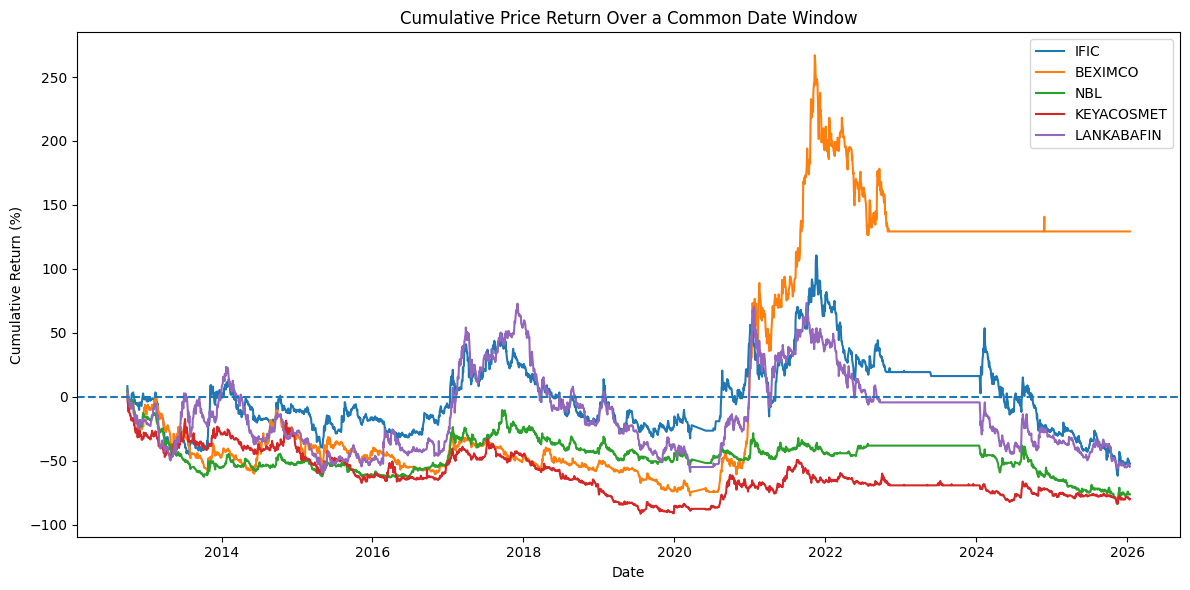

In [165]:
plt.figure(figsize=(12, 6))

for ticker in selected_tickers:
    temp = common_window_df[
        common_window_df["Ticker"] == ticker
    ]

    plt.plot(
        temp["Date"],
        temp["Common_Cumulative_Return_Pct"],
        label=ticker
    )

plt.axhline(0, linestyle="--")

plt.title("Cumulative Price Return Over a Common Date Window")
plt.xlabel("Date")
plt.ylabel("Cumulative Return (%)")
plt.legend()
plt.tight_layout()
plt.show()

In [166]:
common_summary.sort_values(
    "Common_Cumulative_Return_Pct",
    ascending=False
)

,Ticker,Start_Date,End_Date,Trading_Days,Avg_Daily_Return,Return_Volatility,Avg_Daily_Volume,Max_30D_Volatility,Common_Cumulative_Return_Pct
0,BEXIMCO,2012-10-01,2026-01-14,3015,0.06,2.36,"3,555,055.07",6.22,129.33
1,IFIC,2012-10-01,2026-01-14,3147,0.00,2.23,"3,586,836.22",4.79,-52.23
3,LANKABAFIN,2012-10-01,2026-01-14,3128,0.01,2.64,"2,139,740.08",7.61,-54.34
4,NBL,2012-10-01,2026-01-14,3081,-0.03,2.00,"3,034,744.21",5.72,-76.11
2,KEYACOSMET,2012-10-01,2026-01-14,3150,-0.01,3.02,"2,681,217.33",12.07,-79.70


## Common-Window Comparison

To ensure a fairer comparison, selected equities were evaluated over
the same common date range.

This reduces bias caused by differences in listing dates and historical
coverage.

The comparison includes:
- Average daily return
- Return volatility
- Average daily trading volume
- Maximum 30-day volatility
- Cumulative price return

In [167]:
print("Selected Tickers:", selected_tickers)
print("Common Start Date:", common_start)
print("Common End Date:", common_end)

common_summary

Selected Tickers: ['IFIC', 'BEXIMCO', 'NBL', 'KEYACOSMET', 'LANKABAFIN']
Common Start Date: 2012-10-01 00:00:00
Common End Date: 2026-01-14 00:00:00


,Ticker,Start_Date,End_Date,Trading_Days,Avg_Daily_Return,Return_Volatility,Avg_Daily_Volume,Max_30D_Volatility,Common_Cumulative_Return_Pct
0,BEXIMCO,2012-10-01,2026-01-14,3015,0.06,2.36,"3,555,055.07",6.22,129.33
1,IFIC,2012-10-01,2026-01-14,3147,0.00,2.23,"3,586,836.22",4.79,-52.23
2,KEYACOSMET,2012-10-01,2026-01-14,3150,-0.01,3.02,"2,681,217.33",12.07,-79.70
3,LANKABAFIN,2012-10-01,2026-01-14,3128,0.01,2.64,"2,139,740.08",7.61,-54.34
4,NBL,2012-10-01,2026-01-14,3081,-0.03,2.00,"3,034,744.21",5.72,-76.11


# **Power BI preparation**

In [168]:
import os

export_path = "/content/drive/MyDrive/DSE_Market_Analysis/powerbi_data"

os.makedirs(export_path, exist_ok=True)

print(export_path)

/content/drive/MyDrive/DSE_Market_Analysis/powerbi_data


In [169]:
master_df.to_csv(
    export_path + "/dse_equity_master.csv",
    index=False
)

print("Master dataset exported.")

Master dataset exported.


In [170]:
trading_activity.to_csv(
    export_path + "/trading_activity_summary.csv",
    index=False
)

In [171]:
return_summary.to_csv(
    export_path + "/return_summary.csv",
    index=False
)

In [172]:
volatility_summary.to_csv(
    export_path + "/volatility_summary.csv",
    index=False
)

In [173]:
common_summary.to_csv(
    export_path + "/common_window_summary.csv",
    index=False
)

In [174]:
ticker_coverage.to_csv(
    export_path + "/ticker_coverage.csv",
    index=False
)

In [175]:
os.listdir(export_path)

['dse_equity_master.csv',
 'trading_activity_summary.csv',
 'return_summary.csv',
 'volatility_summary.csv',
 'common_window_summary.csv',
 'ticker_coverage.csv']

In [176]:
master_df.columns.tolist()

['Date',
 'Ticker',
 'Open',
 'High',
 'Low',
 'Close',
 'Volume',
 'Daily_Return_Pct',
 'Price_Change',
 'Price_Change_Pct',
 'Trading_Range',
 'Trading_Range_Pct',
 'MA_7',
 'MA_30',
 'Volatility_30',
 'Volume_Change_Pct',
 'Year',
 'Abs_Daily_Return_Pct']

In [177]:
powerbi_test = pd.read_csv(
    export_path + "/dse_equity_master.csv"
)

print(powerbi_test.shape)
powerbi_test.head()

(995906, 18)


,Date,Ticker,Open,High,Low,Close,Volume,Daily_Return_Pct,Price_Change,Price_Change_Pct,Trading_Range,Trading_Range_Pct,MA_7,MA_30,Volatility_30,Volume_Change_Pct,Year,Abs_Daily_Return_Pct
0,2017-10-02,AAMRANET,66.24,122.52,66.24,114.76,5693595,NaN,48.52,73.24,56.28,84.96,NaN,NaN,NaN,NaN,2017,NaN
1,2017-10-03,AAMRANET,114.35,120.07,104.47,105.77,962089,-7.83,-8.58,-7.50,15.60,13.64,NaN,NaN,NaN,-83.10,2017,7.83
2,2017-10-04,AAMRANET,102.92,116.31,102.18,116.31,2367700,9.96,13.40,13.02,14.13,13.73,NaN,NaN,NaN,146.10,2017,9.96
3,2017-10-05,AAMRANET,118.52,127.91,116.80,118.03,2052356,1.47,-0.49,-0.41,11.11,9.37,NaN,NaN,NaN,-13.32,2017,1.47
4,2017-10-08,AAMRANET,117.62,121.29,109.45,111.08,2246879,-5.88,-6.53,-5.56,11.84,10.07,NaN,NaN,NaN,9.48,2017,5.88
